In [ ]:
  import kagglehub
# Download latest version
path = kagglehub.dataset_download("sid321axn/malicious-urls-dataset")
print("Path to dataset files:", path)

100%|██████████| 16.9M/16.9M [00:03<00:00, 5.36MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sid321axn/malicious-urls-dataset/versions/1


In [ ]:
import pandas as pd
import os

# 1. Setup path (using your logic)
base_path = path
files = os.listdir(base_path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(base_path, csv_file)

# 2. Load data
data = pd.read_csv(full_path)

# 3. Print Total Rows
print(f"Total rows in dataset: {len(data)}")


print("\nRows per class:")
print(data['type'].value_counts())

Total rows in dataset: 651191

Rows per class:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# 1. Define your specific targets for each class
custom_targets = {
    'benign': 45000,
    'defacement': 54000,
    'phishing': 48000,
    'malware': 40000
}

# 2. Separate Features and Labels
X = data[['url']]
y = data['type']

under_strategy = {k: v for k, v in custom_targets.items() if len(data[data['type'] == k]) > v}
rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
X_temp, y_temp = rus.fit_resample(X, y)


over_strategy = {k: v for k, v in custom_targets.items() if len(y_temp[y_temp == k]) < v}
ros = RandomOverSampler(sampling_strategy=over_strategy, random_state=42)
X_final, y_final = ros.fit_resample(X_temp, y_temp)


balanced_data = pd.DataFrame(X_final)
balanced_data['type'] = y_final


print("Final Custom Class Distribution:")
print(balanced_data['type'].value_counts())

Final Custom Class Distribution:
type
defacement    54000
phishing      48000
benign        45000
malware       40000
Name: count, dtype: int64


In [ ]:
print(balanced_data.sample(5))

                                                     url        type
82747  http://wandern-in-griechenland.de/fotogalerie/...  defacement
7057   acronyms.thefreedictionary.com/Short+Acting+Be...      benign
15017   amazon.com/ATI-Rage-8MB-Video-Card/dp/B000G6U2W4      benign
57195  http://codep34.fr/index.php?option=com_content...  defacement
2897   us.battle.net.en.qe-rs.com/login/en/login.html...      benign


In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

balanced_data["type"]=le.fit_transform(balanced_data["type"])

In [ ]:
print(balanced_data.sample(4))

                                                      url  type
118421                  http://182.127.79.81:43215/Mozi.m     2
169124                        tools.ietf.org/html/rfc1628     3
22559   plaxo.com/directory/profile/214749250760/d8e8e...     0
117879     https://chinatyres.net/IuNbOpen/15osndo411.exe     2


In [ ]:
y=balanced_data["type"]
x=balanced_data.drop(columns=["type"])

print(x.head(4))

                                                url
0  montreal.louer.com/ahuntsic-rentals/houses-rent/
1      comunidade.sol.pt/blogs/hytigin/default.aspx
2                   youtube.com/watch?v=PUDOlyCpHwo
3                    uiowa.edu/~acadtech/phonetics/


In [ ]:
import re

def clean_url(url):

    url = url.lower()


    url = re.sub(r'^https?://', '', url)


    url = re.sub(r'^www\.', '', url)


    url = url.rstrip('/')



    return url


balanced_data['cleaned_url'] = balanced_data['url'].apply(clean_url)


print(balanced_data[['url', 'cleaned_url']].head(3))

                                                url  \
0  montreal.louer.com/ahuntsic-rentals/houses-rent/   
1      comunidade.sol.pt/blogs/hytigin/default.aspx   
2                   youtube.com/watch?v=PUDOlyCpHwo   

                                       cleaned_url  
0  montreal.louer.com/ahuntsic-rentals/houses-rent  
1     comunidade.sol.pt/blogs/hytigin/default.aspx  
2                  youtube.com/watch?v=pudolycphwo  


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split


tokenizer = Tokenizer(char_level=True, lower=True)
tokenizer.fit_on_texts(balanced_data['cleaned_url'])


sequences = tokenizer.texts_to_sequences(balanced_data['cleaned_url'])


max_url_len = 100
X = pad_sequences(sequences, maxlen=max_url_len, padding='post')





X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

print(f"X_train Shape: {X_train.shape}")
print(f"y_train Shape: {y_train.shape}")




print("Sample X_train (Numerical Sequences):")
print(X_train[:2])




print("Sample y_train (Class Labels):")
print(y_train[:10])


reverse_word_map = {v: k for k, v in tokenizer.word_index.items()}
sample_url = "".join([reverse_word_map.get(i, "") for i in X_train[0] if i != 0])

print(f"Decoded Sample URL from X_train: {sample_url}")

X_train Shape: (149600, 100)
y_train Shape: (149600,)
Sample X_train (Numerical Sequences):
[[ 5 16  1  7 16  1  1 36  2 25 16  1 11  9  7  2  8 12  6  1 27 10 12 24
  31 39 17  5 16  1 17  7 16  1  1 36 17  2 25 17 16  1 11 17 15 11  1 10
   1  6  5  1 14 17  2  6 17 10 36 30 13  3 21 16  5 17 21 11  1  1  7  1
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0]
 [24 38  9 32 20  9 24 20 24  9 20 20 39 45 32 29 39 20 26 12  8  2 42  3
   9  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0]]
Sample y_train (Class Labels):
64968     1
116086    2
6771      0
59558     1
106457    2
163632    3
132464    3
28521     0
72874     1
6724      0
Name: type, dtype: int64
Decoded Sample URL from X_train: thecheekofher.com/news/296-the-cheek-of-her-presented-on-skylight-greece


## Conditional Model Loading and Training

To save time, the notebook will first check if a trained model, tokenizer, and label encoder already exist in Google Drive. If they do, they will be loaded directly, skipping the training process. If not, a new model will be trained and then saved.

In [ ]:
from google.colab import drive
import os
import pickle
from tensorflow.keras.models import load_model

# Mount Google Drive for persistent storage
drive.mount('/content/drive')

# Define paths for saving/loading assets
MODEL_PATH = "/content/drive/MyDrive/malicious_url_model2.keras"
TOKENIZER_PATH = "/content/drive/MyDrive/tokenizer.pkl"
ENCODER_PATH = "/content/drive/MyDrive/label_encoder.pkl"

# Check if model already exists and load it
if os.path.exists(MODEL_PATH) and os.path.exists(TOKENIZER_PATH) and os.path.exists(ENCODER_PATH):
    print("✅ Loading existing model and assets from Google Drive...")
    model = load_model(MODEL_PATH)
    with open(TOKENIZER_PATH, "rb") as f:
        tokenizer = pickle.load(f)
    with open(ENCODER_PATH, "rb") as f:
        le = pickle.load(f)
    model_loaded = True
    print("Model and assets loaded successfully!")
else:
    print("⚠️ Model not found in Google Drive. Proceeding with model training...")
    model_loaded = False

Mounted at /content/drive
✅ Loading existing model and assets from Google Drive...
Model and assets loaded successfully!


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D

vocab_size = len(tokenizer.word_index) + 1


model = Sequential([

    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_url_len),


    SpatialDropout1D(0.2),


    Bidirectional(LSTM(64, return_sequences=False)),


    Dense(64, activation='relu'),
    Dropout(0.5),


    Dense(4, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# 2. Pass it into the model.fit
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.6339 - loss: 0.8556 - val_accuracy: 0.7274 - val_loss: 0.6672
Epoch 2/60
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.7445 - loss: 0.6323 - val_accuracy: 0.7828 - val_loss: 0.5255
Epoch 3/60
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.7860 - loss: 0.5327 - val_accuracy: 0.8047 - val_loss: 0.4723
Epoch 4/60
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8066 - loss: 0.4813 - val_accuracy: 0.8238 - val_loss: 0.4288
Epoch 5/60
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8181 - loss: 0.4501 - val_accuracy: 0.8331 - val_loss: 0.4096
Epoch 6/60
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8275 - loss: 0.4283 - val_accuracy: 0.8389 - val_loss: 0.3885
Epoch 7/60
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8350 - loss: 0.4058 - val_accuracy: 0.8478 - val_loss: 0.3743
Epoch 8/60
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8424 -

1169/1169 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step


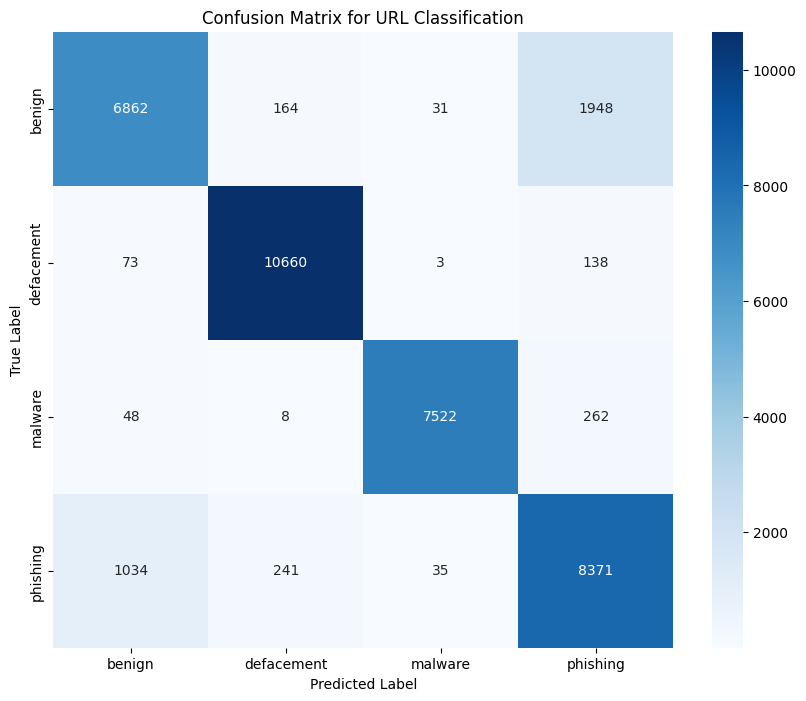

              precision    recall  f1-score   support

      benign       0.86      0.76      0.81      9005
  defacement       0.96      0.98      0.97     10874
     malware       0.99      0.96      0.97      7840
    phishing       0.78      0.86      0.82      9681

    accuracy                           0.89     37400
   macro avg       0.90      0.89      0.89     37400
weighted avg       0.90      0.89      0.89     37400



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for URL Classification')
plt.show()


print(classification_report(y_test, y_pred, target_names=le.classes_))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pickle

# Save Model
model.save("/content/drive/MyDrive/malicious_url_model2.keras")

# Save Tokenizer
with open("/content/drive/MyDrive/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save Label Encoder
with open("/content/drive/MyDrive/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("✅ Model saved permanently in Google Drive!")

✅ Model saved permanently in Google Drive!


## Model Performance Report

### 1. Model Architecture

In [1]:
!pip install python-whois

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 5.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import re
import numpy as np
import pickle
import socket
import ssl
from datetime import datetime
import whois
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

MODEL_PATH = "/content/drive/MyDrive/malicious_url_model2.keras"
TOKENIZER_PATH = "/content/drive/MyDrive/tokenizer.pkl"
ENCODER_PATH = "/content/drive/MyDrive/label_encoder.pkl"

model = load_model(MODEL_PATH)

with open(TOKENIZER_PATH, "rb") as f:
    tokenizer = pickle.load(f)

with open(ENCODER_PATH, "rb") as f:
    le = pickle.load(f)

print("✅ Model and files loaded successfully!")

def clean_url(url):
    url = url.lower()
    url = re.sub(r'^https?://', '', url)
    url = re.sub(r'^www\.', '', url)
    url = url.rstrip('/')
    return url

def ml_predict(url):
    cleaned = clean_url(url)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=100, padding='post')
    pred = model.predict(padded, verbose=0)
    class_index = np.argmax(pred)
    return le.inverse_transform([class_index])[0]

def extract_features(url):
    return {
        "length": len(url),
        "dots": url.count('.'),
        "has_login": int("login" in url),
        "has_secure": int("secure" in url),
        "has_ip": int(bool(re.search(r'\d+\.\d+\.\d+\.\d+', url)))
    }

def get_domain_age(url):
    try:
        domain = clean_url(url).split('/')[0]
        info = whois.whois(domain)
        if info.creation_date:
            creation_date = info.creation_date[0] if isinstance(info.creation_date, list) else info.creation_date
            return (datetime.now() - creation_date).days
    except:
        pass
    return -1

def check_ssl(domain):
    try:
        ctx = ssl.create_default_context()
        with socket.create_connection((domain, 443), timeout=3) as sock:
            with ctx.wrap_socket(sock, server_hostname=domain):
                return True
    except:
        return False

def final_predict(url):
    risk = 0
    reasons = []
    ml_result = ml_predict(url)
    if ml_result != "benign":
        risk += 2
        reasons.append(f"ML detected {ml_result}")
    features = extract_features(url)
    if features["has_login"]:
        risk += 1
        reasons.append("Contains 'login'")
    if features["has_secure"]:
        risk += 1
        reasons.append("Contains 'secure'")
    if features["has_ip"]:
        risk += 2
        reasons.append("Uses IP instead of domain")
    age = get_domain_age(url)
    if age != -1 and age < 30:
        risk += 2
        reasons.append("Very new domain")
    domain = clean_url(url).split('/')[0]
    if not check_ssl(domain):
        risk += 2
        reasons.append("No valid SSL")
    if risk >= 5:
        verdict = "🚨 Dangerous"
    elif risk >= 3:
        verdict = "⚠️ Suspicious"
    else:
        verdict = "✅ Safe"
    return {
        "url": url,
        "ml_prediction": ml_result,
        "risk_score": risk,
        "final_verdict": verdict,
        "reasons": reasons
    }

urls = [
    "http://google.com",
    "https://www.facebook.com",
    "http://free-money-login-bank.xyz",
    "https://paypal-secure-login-alert.com",
    "http://192.168.10.129/login.php",
    "https://www.facebook.com/",
    "http://secure-login-paypal.com.verify-user.ru"
]

for u in urls:
    result = final_predict(u)
    print("\n🌐 URL:", result["url"])
    print("🤖 ML:", result["ml_prediction"])
    print("🚦 Final:", result["final_verdict"])
    print("📌 Reasons:", result["reasons"])

Mounted at /content/drive
✅ Model and files loaded successfully!

🌐 URL: http://google.com
🤖 ML: benign
🚦 Final: ✅ Safe
📌 Reasons: []

🌐 URL: https://www.facebook.com
🤖 ML: phishing
🚦 Final: ✅ Safe
📌 Reasons: ['ML detected phishing']

🌐 URL: http://free-money-login-bank.xyz
🤖 ML: phishing
🚦 Final: 🚨 Dangerous
📌 Reasons: ['ML detected phishing', "Contains 'login'", 'No valid SSL']

🌐 URL: https://paypal-secure-login-alert.com
🤖 ML: phishing
🚦 Final: 🚨 Dangerous
📌 Reasons: ['ML detected phishing', "Contains 'login'", "Contains 'secure'", 'No valid SSL']

🌐 URL: http://192.168.10.129/login.php
🤖 ML: malware
🚦 Final: 🚨 Dangerous
📌 Reasons: ['ML detected malware', "Contains 'login'", 'Uses IP instead of domain', 'No valid SSL']

🌐 URL: https://www.facebook.com/
🤖 ML: phishing
🚦 Final: ✅ Safe
📌 Reasons: ['ML detected phishing']

🌐 URL: http://secure-login-paypal.com.verify-user.ru
🤖 ML: phishing
🚦 Final: 🚨 Dangerous
📌 Reasons: ['ML detected phishing', "Contains 'login'", "Contains 'secure'",